<a href="https://colab.research.google.com/github/e-junior/Grupo16TechChallenge/blob/main/exportacao_vinho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd


In [2]:
df_exp_vinho = pd.read_csv('ExpVinhoPivot.csv')

In [3]:
df_exp_vinho.head()

,Id,País,Ano,Quantidade,Valor (USD)
0,1,Afeganistão,1970,0,0
1,1,Afeganistão,1971,0,0
2,1,Afeganistão,1972,0,0
3,1,Afeganistão,1973,0,0
4,1,Afeganistão,1974,0,0


In [4]:
#recorte dos últimos 15 anos
df_exp_vinho_filtrado = df_exp_vinho[df_exp_vinho['Ano'] > 2007]

In [5]:
#verificação de números nulos
df_exp_vinho_filtrado.isnull().sum().sum()

np.int64(0)

In [6]:
#renomeando colunas
df_exp_vinho_filtrado.columns = [ 'id', 'pais', 'ano', 'quantidade', 'valor']
#retirando coluna id
df_exp_vinho_filtrado.drop('id', axis=1, inplace = True)

/tmp/ipython-input-6-1690708918.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp_vinho_filtrado.drop('id', axis=1, inplace = True)


In [7]:
#verificando tipos dos dados
#df_exp_vinho_filtrado.dtypes
#convertendo coluna ano de tipo int para str
df_exp_vinho_filtrado['ano'] = df_exp_vinho_filtrado['ano'].astype(str)

/tmp/ipython-input-7-2414790282.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp_vinho_filtrado['ano'] = df_exp_vinho_filtrado['ano'].astype(str)


In [8]:
#top5 maiores volumes de exportação num unico ano
analise_volume = df_exp_vinho_filtrado.sort_values(by='quantidade', ascending=False)
analise_volume.head(5)

,pais,ano,quantidade,valor
6364,Rússia,2009,21912914,5732280
5881,Paraguai,2021,6522527,7192362
6363,Rússia,2008,6207658,2352768
6368,Rússia,2013,5893291,14795694
5882,Paraguai,2022,5076670,7156293


In [9]:
#buscando top5 maiores exportadores por volume
analise_volume_gp =  df_exp_vinho_filtrado.groupby(['pais'])['quantidade'].sum()

analise_volume_gp.sort_values(ascending=False).head(5)

,quantidade
pais,
Rússia,39029855
Paraguai,36700416
Estados Unidos,4103604
Haiti,2801938
China,2617606


In [10]:
#top5 maiores valores de exportação num unico ano
analise_valor = df_exp_vinho_filtrado.sort_values(by='valor', ascending=False)
analise_valor.head(5)

,pais,ano,quantidade,valor
6368,Rússia,2013,5893291,14795694
5881,Paraguai,2021,6522527,7192362
5882,Paraguai,2022,5076670,7156293
6364,Rússia,2009,21912914,5732280
5883,Paraguai,2023,3780378,5517263


In [11]:
#buscando top5 maiores exportadores por valor
analise_valor_gp =  df_exp_vinho_filtrado.groupby(['pais'])['valor'].sum()

analise_valor_gp.sort_values(ascending=False).head(5)

,valor
pais,
Paraguai,49358151
Rússia,25504822
Estados Unidos,10762382
China,5112216
Reino Unido,4902724


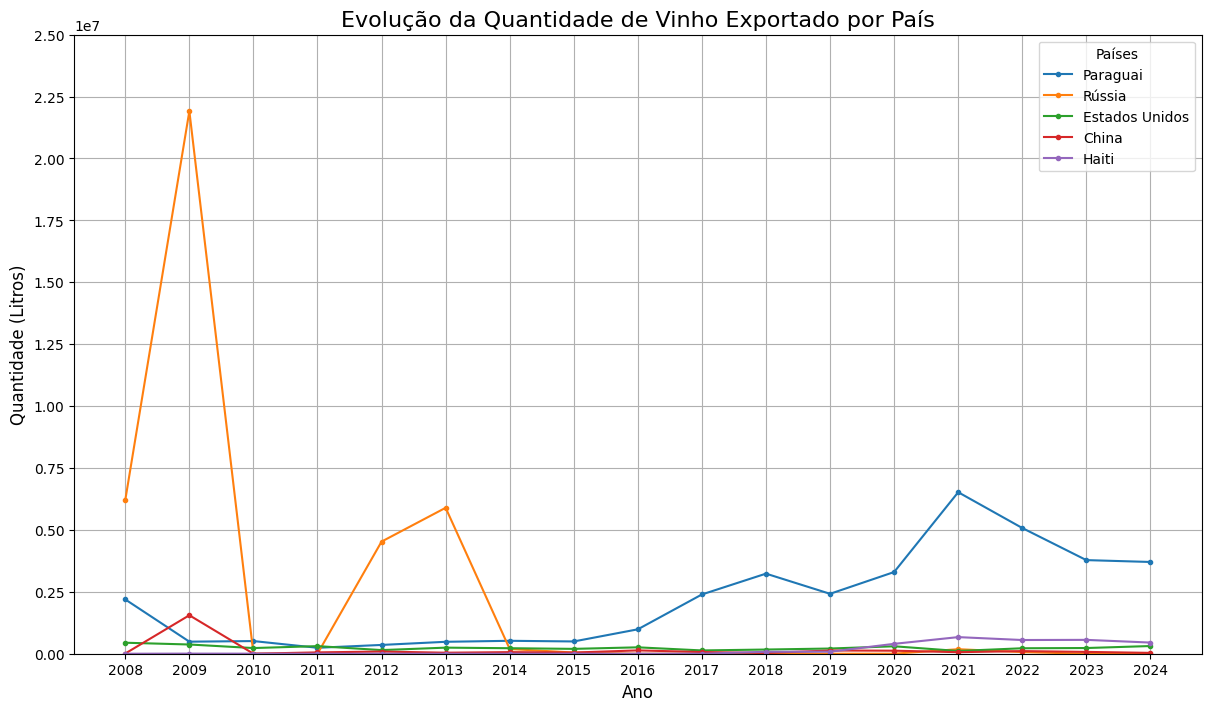

In [12]:
paises_para_plotar = ['Paraguai', 'Rússia', 'Estados Unidos', 'China', 'Haiti']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Evolução da Quantidade de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 25_000_000)
ticks_person = np.arange(0, 25_000_001, 2_500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

##Analises contextualizadas
motivos de queda da exportação em volume da russia:
*crise economica e valorizacao R$ x U$D, consequente mudanças na politica de importação
*entre 2011-14 - aumento do petroleo favoreceu economia da russia

comportamento Paraguai
*Distancia reduzida do polo produtor e consumidor
*O Paraguai tem uma carga tributária menor em comparação com o Brasil, o que torna os vinhos, tanto nacionais quanto importados, mais baratos para o consumidor final

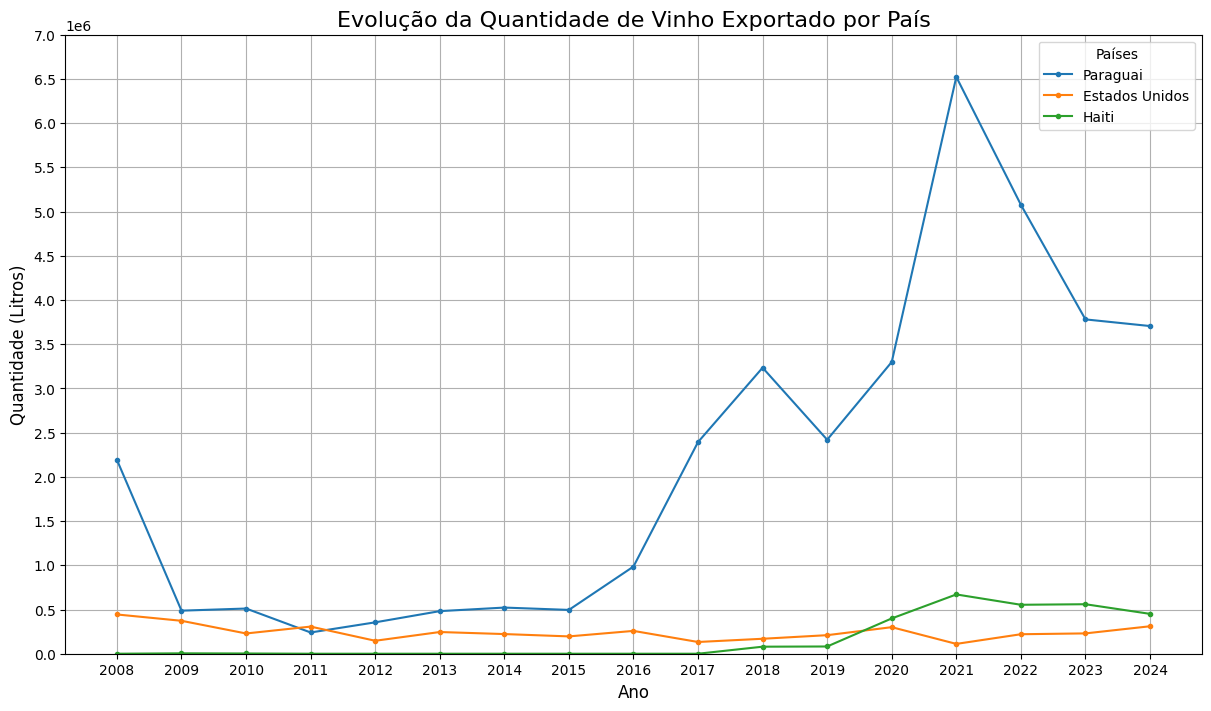

In [13]:
#plotando paises sem china e Russia para visualizar os menores

paises_para_plotar = ['Paraguai',  'Estados Unidos', 'Haiti']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['quantidade'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Evolução da Quantidade de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 7_000_000)
ticks_person = np.arange(0, 7_000_001, 500_000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

##Analise contextualizada
Paraguai
*diminuição do consumo de 2020~
multifatorial e incerto
- flutuação cambial? - da pra checar
- preferencia do consumidor/comportamento
-concorrencia - vinhos chilenos e argentinos tem mais facilidade?

Haiti
- possui dois acordos comerciais que dificultam expansao (caricom - comunidade do Caribe) e EPA- parceria economica com os EUA...  tornam o eixo de comercio com certa vantagem para os Eua e caribenhos. Proporcionalmente como é Brasil e demais paises membros do Mercosul. Lembrando que Haiti nao possui nenhum acordo especifico para uvas ou vinhos.



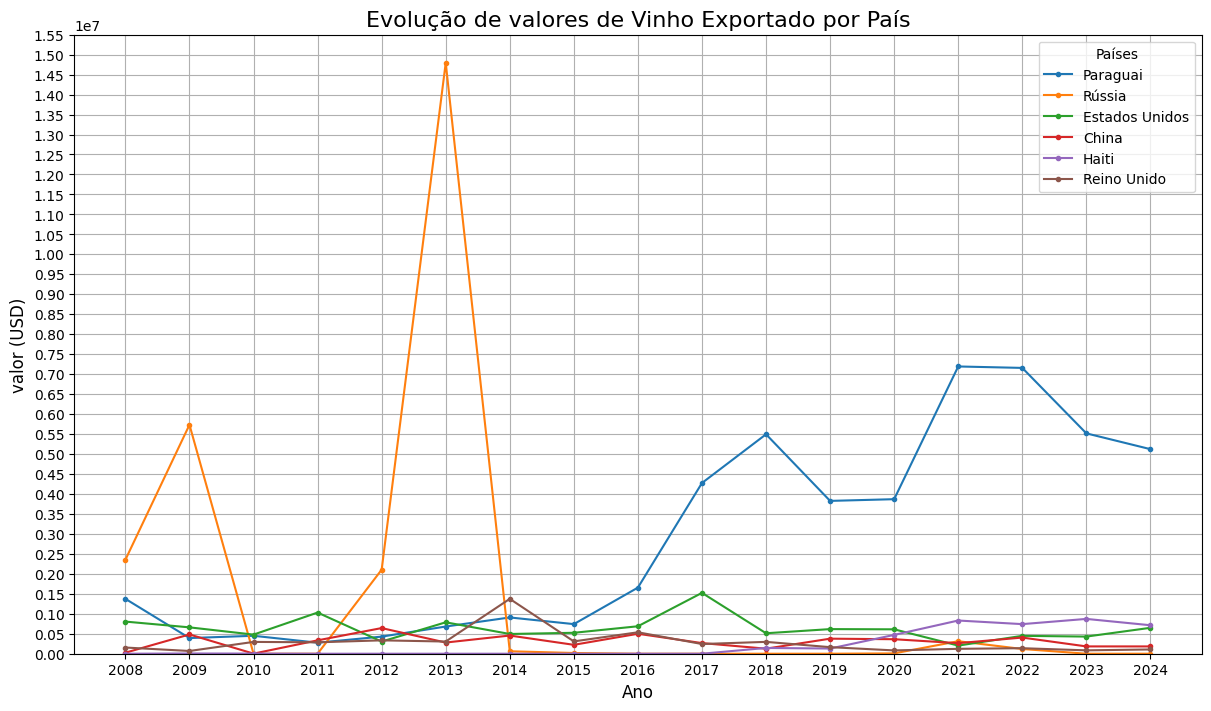

In [15]:
paises_para_plotar = ['Paraguai', 'Rússia', 'Estados Unidos', 'China', 'Haiti', 'Reino Unido']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 15_500_000)
ticks_person = np.arange(0, 15_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

vale a pena fazer analise para o mercosul?

Nao houve destaques para estudos que viesse a trazer algum insight em vista de que os comercios de  Argentina, Uruguai, Chile e Paraguai sao inundados por vinhos europeus (França, Portugal, Italia, Espanha)

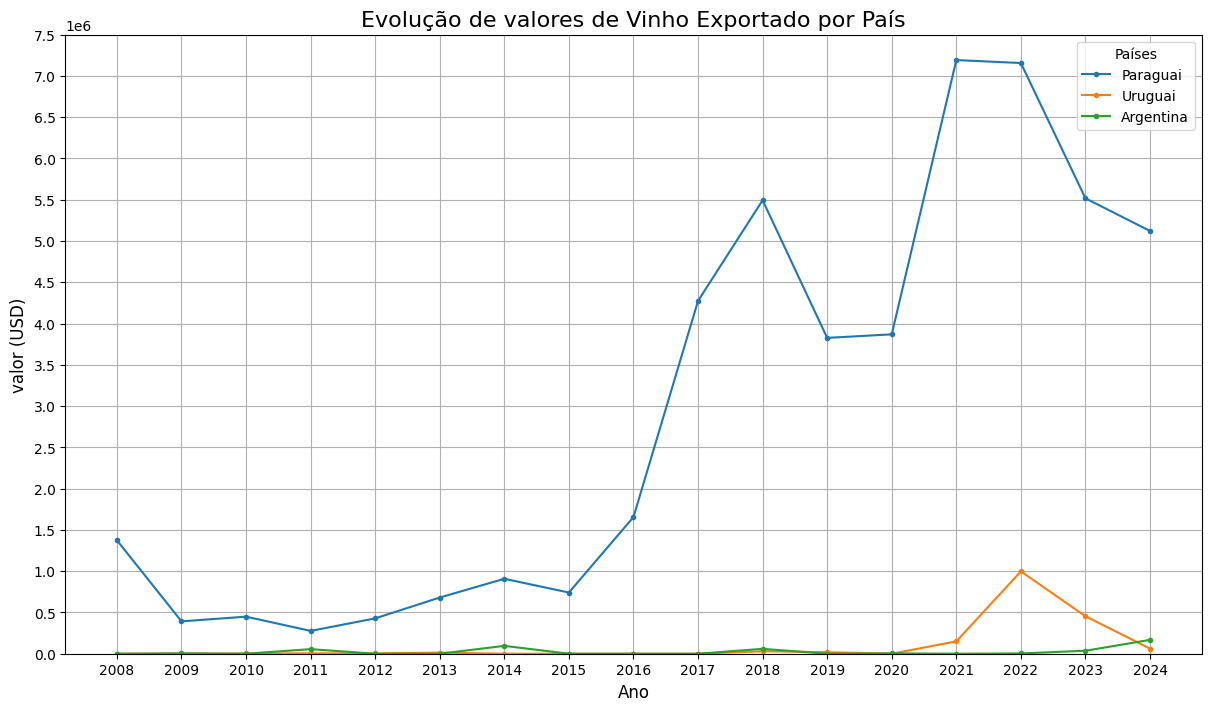

In [18]:
paises_para_plotar = ['Paraguai', 'Uruguai', 'Argentina']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 7_500_000)
ticks_person = np.arange(0, 7_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

Analise para o Brics, vale a pena?
(acordo comercial entre os membros que não perpassam sobre o valor do dolar, diminuindo o desequilibrio cambial entre os participantes)
(Não pus Russia no gráfico porque fica distoante por tamanho muito grande)
India e Africa do Sul são inexpressivos, talvez por questoes culturais.
China e Rússia se destacam....

**pode vir a ser um bom mercado em vista de ter acordos comerciais que diminuem a desvantagem cambial **

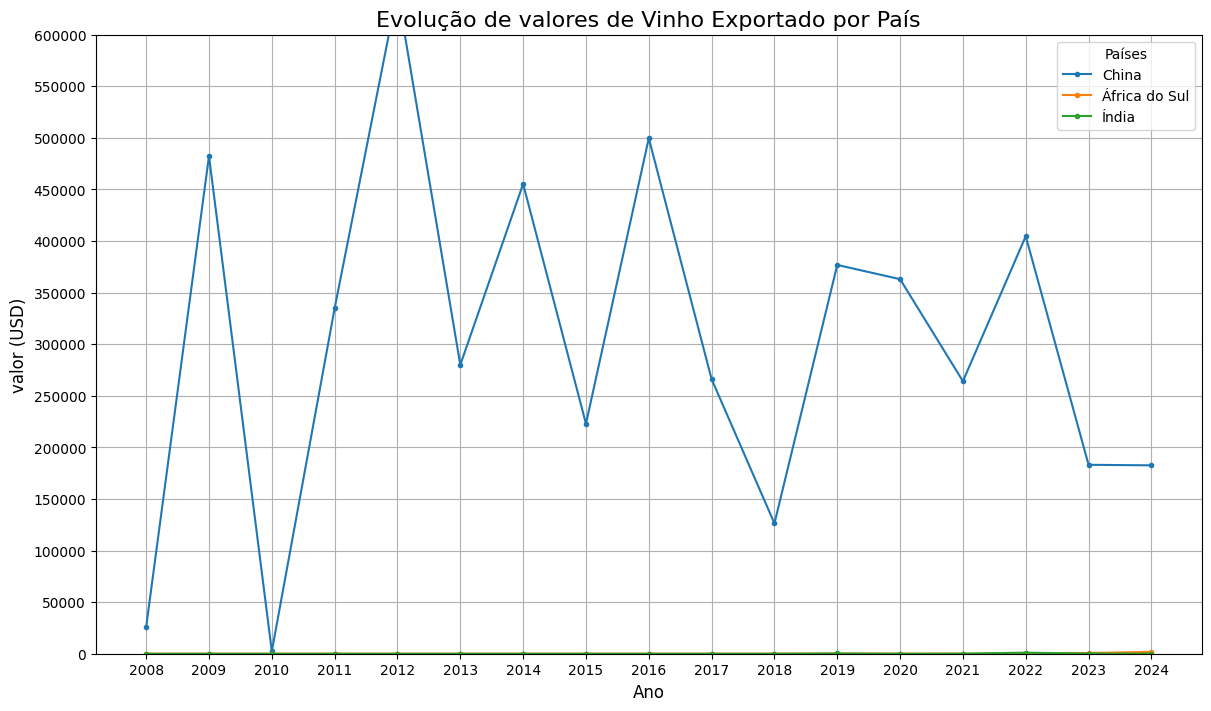

In [22]:
paises_para_plotar = ['China', 'África do Sul', 'Índia']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 600_000)
ticks_person = np.arange(0, 600_001, 50_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

nao sei dizer qual paga melhor pelo vinho importado china,russia ou paraguai


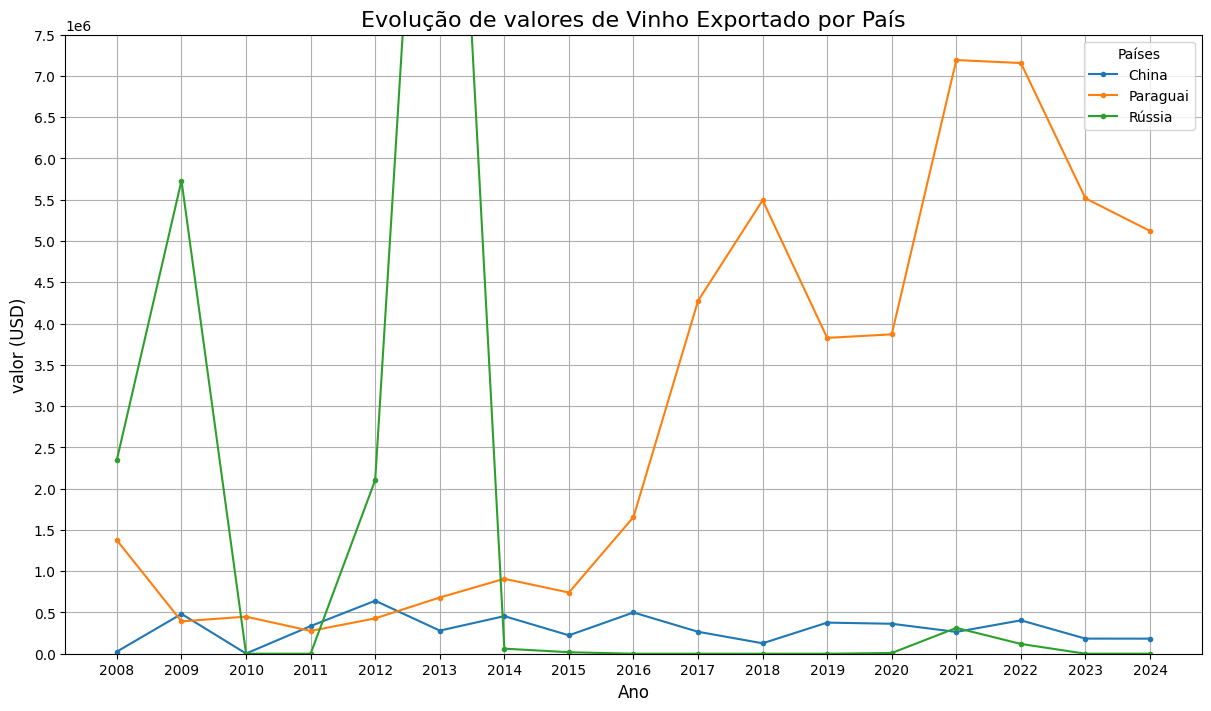

In [23]:
paises_para_plotar = ['China', 'Paraguai', 'Rússia']
df_filtrado = df_exp_vinho_filtrado[ df_exp_vinho_filtrado['pais'].isin(paises_para_plotar)]

# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')


    ax.plot(df_pais['ano'], df_pais['valor'], marker='.', linestyle='-', label=pais)


ax.set_title('Evolução de valores de Vinho Exportado por País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('valor (USD)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo


ax.legend(title='Países')
ax.set_ylim(0, 7_500_000)
ticks_person = np.arange(0, 7_500_001, 500_000)
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

olhando para o paraguai

/tmp/ipython-input-26-3561364352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


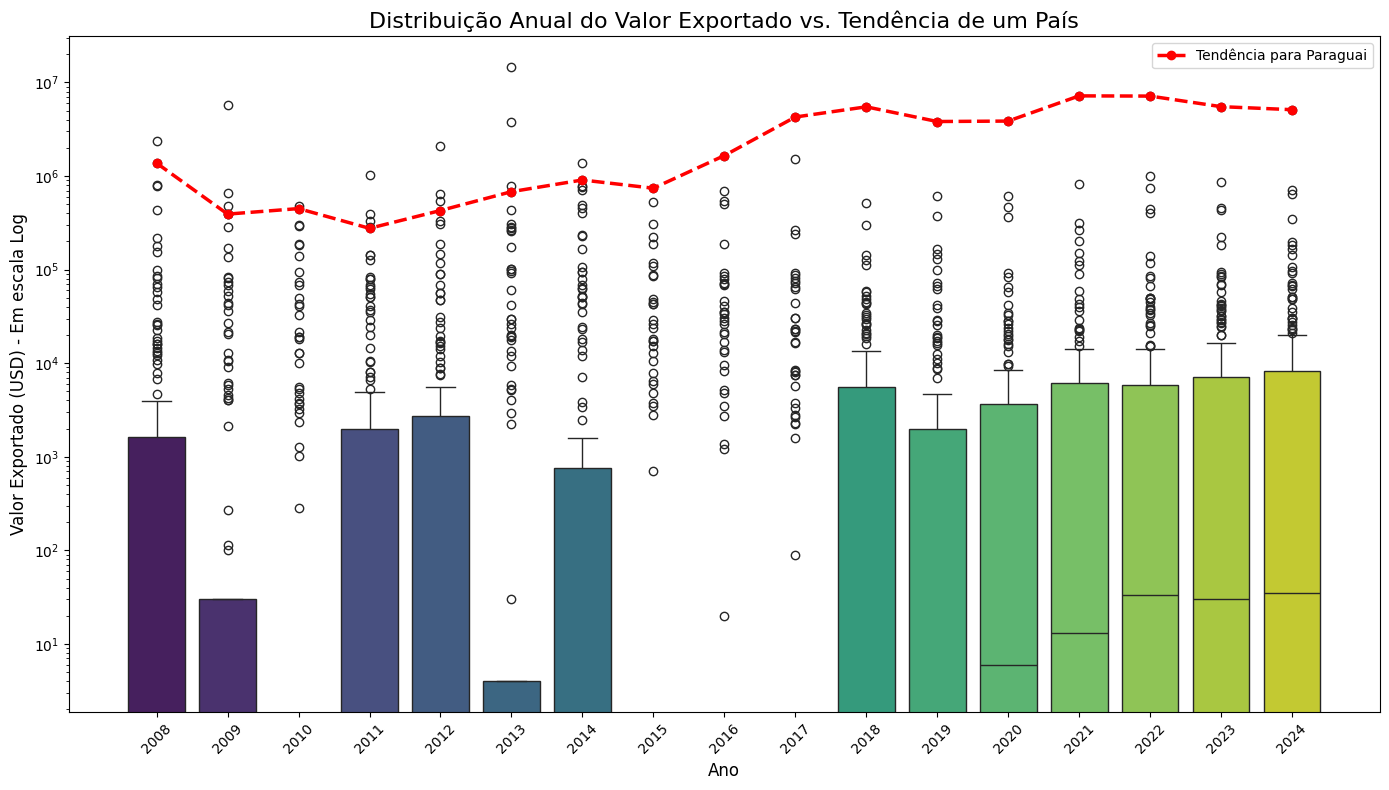

In [26]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Paraguai'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()


olhando para China

/tmp/ipython-input-27-839853237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


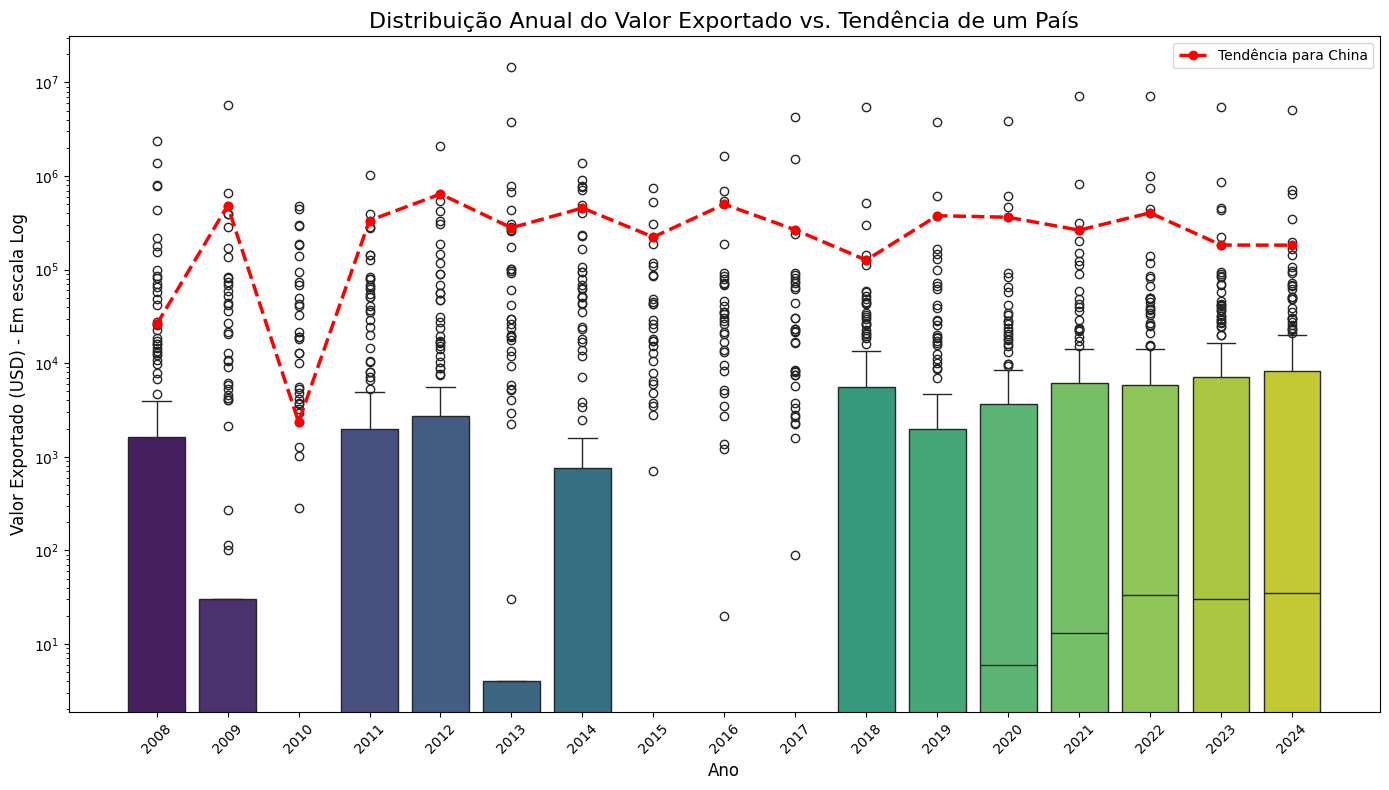

In [27]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'China'
#____________________________

df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()


/tmp/ipython-input-32-2086363776.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)


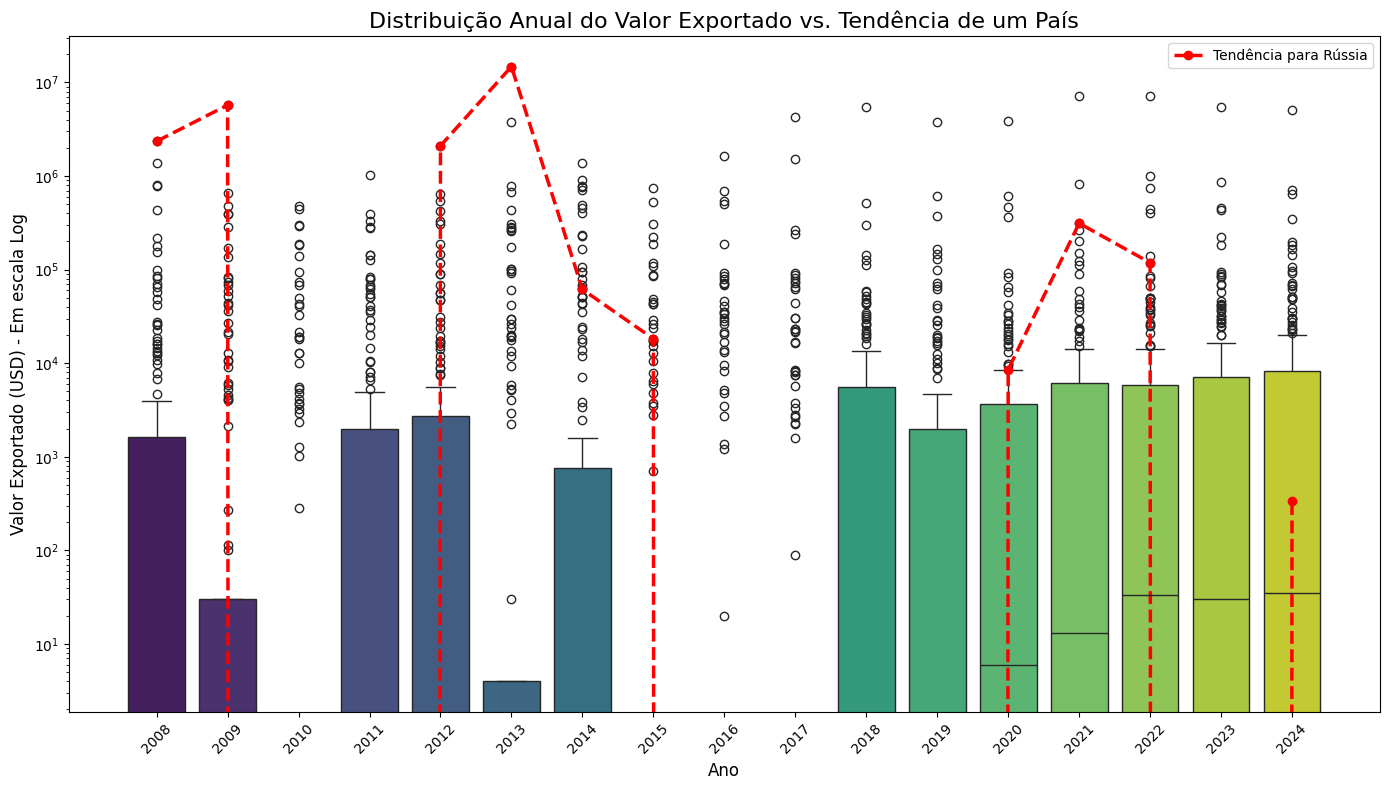

In [32]:
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Desenhe o boxplot no eixo 'ax'
sns.boxplot(data=df_exp_vinho_filtrado, x='ano', y='valor', palette='viridis', ax=ax)
ax.set_title('Distribuição Anual do Valor Exportado vs. Tendência de um País', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valor Exportado (USD) - Em escala Log', fontsize=12)

# O valor tem uma variação muito grande, uma escala logarítmica ajuda a visualizar os boxplots
ax.set_yscale('log')


# 4. Prepare os dados do país que você quer destacar
pais_destacado = 'Rússia'
df_pais = df_exp_vinho_filtrado[df_exp_vinho_filtrado['pais'] == pais_destacado].sort_values('ano')


# 5. Adicione a linha de informação do país NO MESMO EIXO 'ax'
# Usamos ax.plot() para desenhar a linha por cima
ax.plot(
    df_pais['ano'].astype(str),  # Garante que o eixo x seja tratado da mesma forma que o boxplot
    df_pais['valor'],
    color='red',                # Cor que se destaca
    marker='o',                 # Marcador em cada ponto de dado
    linestyle='--',             # Linha tracejada
    linewidth=2.5,              # Linha mais grossa
    label=f'Tendência para {pais_destacado}' # Legenda para a linha
)


# 6. Ajustes finais
ax.tick_params(axis='x', rotation=45) # Rotaciona os rótulos do eixo X para não sobrepor
ax.legend() # Mostra a legenda que definimos no passo 5
plt.tight_layout() # Ajusta o layout para que nada fique cortado
plt.show()